In [1]:
!pip install ase numpy scipy matplotlib pandas networkx orb-models

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.2/416.2 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 464.2/464.2 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.3/164.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 11.6 MB/s eta 0:00:00
  Created wheel for dm-tree: filename=dm_tree-0.1.8-cp313-cp313-linux_x86_64.whl size=135919 sha256=3d4b34b8c85fdc1bf8bfb530a7469b0591ce974826f680b4b7701c2715ebc995
  Stored in directory: /root/.cache/pip/wheels/67/a2/15/a6aa1b4f084c1b7092f68044144c2b7ffab0a894bde001b6e8
Successfully built dm-tree
  Attempting uninstall: dm-tree
    Found existing installation: dm-tree 0.1.10
    Uninstalling dm-

In [7]:
import io
import warnings
import networkx as nx
import numpy as np
import pandas as pd
import torch
from ase import Atoms
from ase.data import covalent_radii
from ase.io import read
from orb_models.forcefield import pretrained
from orb_models.forcefield.inference.calculator import ORBCalculator

# Molecule XYZ definition
XYZ_DATA = """38
SMILES: CCC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)C
C     -6.4589380000    0.2094310000   -0.4730120000
C     -5.5166560000    0.8765130000    0.5236150000
C     -4.1218880000    1.2963780000   -0.0228640000
C     -4.3743860000    2.3811980000   -1.1180540000
C     -3.3378660000    2.0111970000    1.0906020000
O     -2.8347040000    3.1221280000    0.9761330000
O     -3.2981230000    1.2702530000    2.2292450000
C     -2.6087930000    1.8800890000    3.3244010000
C     -3.2880800000    0.1745490000   -0.7278710000
C     -2.7318800000   -1.1278100000   -0.0469050000
C     -3.6988760000   -1.7198450000    1.0018010000
C     -2.6443390000   -2.2547330000   -1.1135390000
O     -3.1708610000   -2.2196230000   -2.2178050000
O     -1.9348830000   -3.3254770000   -0.6512080000
C     -1.8492450000   -4.4168530000   -1.5695300000
C     -1.7817273030   -0.9962739447    0.4272343452
H     -5.4214420000    0.2221710000    1.3936420000
H     -4.9690700000    3.2140640000   -0.7234520000
H     -3.4317400000    2.8051170000   -1.4853770000
H     -4.8982510000    1.9723230000   -1.9884330000
H     -2.3203080000    1.0884840000    4.0230330000
H     -1.6984090000    2.3984010000    3.0065860000
H     -3.2854900000    2.5714950000    3.8363450000
H     -2.4385840000    0.6681730000   -1.2100270000
H     -3.9090530000   -0.1360810000   -1.5775950000
H     -3.3473520000   -2.6926650000    1.3683570000
H     -3.7924330000   -1.0891080000    1.8866220000
H     -4.6912980000   -1.8994320000    0.5777710000
H     -1.3831830000   -4.0977210000   -2.5069960000
H     -2.8417820000   -4.8405830000   -1.7511260000
H     -1.2202230000   -5.1883310000   -1.1177920000
H     -6.0354110000   -0.7111780000   -0.8815880000
H     -6.0231810000    1.7707500000    0.9153960000
H     -6.7100530000    0.8720720000   -1.3046130000
H     -7.3980770000   -0.0519770000    0.0254250000
H     -1.8528798699   -0.2189338539    1.1590675281
H     -1.4914700774   -1.9092787929    0.9037561204
H     -1.0506792183   -0.7290731255   -0.3069812447
"""


def detect_bonds(atoms: Atoms, skin: float = 0.25):
    """Detects chemical bonds based on covalent radii and builds a NetworkX graph."""
    positions = atoms.get_positions()
    numbers = atoms.get_atomic_numbers()
    num_atoms = len(atoms)

    g = nx.Graph()
    for i in range(num_atoms):
        g.add_node(i, symbol=atoms[i].symbol)

    bonds = []
    for i in range(num_atoms):
        r_i = covalent_radii[numbers[i]]
        for j in range(i + 1, num_atoms):
            r_j = covalent_radii[numbers[j]]
            dist = np.linalg.norm(positions[i] - positions[j])
            cutoff = r_i + r_j + skin
            if dist <= cutoff:
                g.add_edge(i, j, length=dist)
                bonds.append((i, j, dist))
    return g, bonds


def generate_stretched_conformation(
    atoms: Atoms, g: nx.Graph, i: int, j: int, target_dist: float
) -> Atoms:
    """Rigidly shifts fragment containing atom j along bond axis (i -> j) to match target_dist."""
    pos = atoms.get_positions().copy()
    vec = pos[j] - pos[i]
    current_dist = np.linalg.norm(vec)
    direction = vec / current_dist

    # Remove bond to find the rigid fragment connected to atom j
    g_cut = g.copy()
    g_cut.remove_edge(i, j)

    if nx.has_path(g_cut, i, j):
        # Bond is in a cycle (cyclic displacement fallback)
        shift = (target_dist - current_dist) * direction
        pos[j] += shift
    else:
        # Acyclic bond: move entire rigid sub-fragment connected to j
        frag_j = nx.node_connected_component(g_cut, j)
        displacement = (target_dist - current_dist) * direction
        for node in frag_j:
            pos[node] += displacement

    new_atoms = atoms.copy()
    new_atoms.set_positions(pos)
    return new_atoms


def load_calculators(device: str = "cuda" if torch.cuda.is_available() else "cpu"):
    """Instantiates the three benchmark models with ASE ORBCalculator."""
    print(f"Loading MLIP models on device: {device}")
    calculators = {}

    # 1. Orb-v3 Direct (20 or inf)
    print("-> Loading orb_v3_direct_20_omat...")
    try:
        orbff, adapter = pretrained.orb_v3_direct_20_omat(
            device=device, precision="float32-high"
        )
    except AttributeError:
        orbff, adapter = pretrained.orb_v3_direct_inf_omat(
            device=device, precision="float32-high"
        )
    calculators["orb_v3_direct_omat"] = ORBCalculator(
        orbff, atoms_adapter=adapter, device=device
    )

    # 2. Orb-v3 Conservative
    print("-> Loading orb_v3_conservative_20_omat...")
    try:
        orbff, adapter = pretrained.orb_v3_conservative_20_omat(
            device=device, precision="float32-high"
        )
    except AttributeError:
        orbff, adapter = pretrained.orb_v3_conservative_20_omat(
            device=device, precision="float32-high"
        )
    calculators["orb_v3_conservative_omat"] = ORBCalculator(
        orbff, atoms_adapter=adapter, device=device
    )

    # 3. OrbMol-v2
    print("-> Loading orbmol_v2...")
    orbff, adapter = pretrained.orbmol_v2(device=device, precision="float32-high")
    calculators["orbmol_v2"] = ORBCalculator(
        orbff, atoms_adapter=adapter, device=device
    )

    return calculators


def main():
    # Read molecular geometry
    mol = read(io.StringIO(XYZ_DATA), format="xyz")

    # OrbMol potentials require explicit net charge and spin multiplicity (2S + 1)
    mol.info["charge"] = 0
    mol.info["spin"] = 1

    graph, bonds = detect_bonds(mol)
    print(f"Total atoms: {len(mol)} | Total detected covalent bonds: {len(bonds)}")

    calcs = load_calculators()

    # Scan grid: 11 points from compressed (0.8x) to dissociation stretch (2.2x)
    stretch_factors = np.linspace(0.8, 2.2, 15)

    results = []

    for b_idx, (i, j, r0) in enumerate(bonds):
        sym_i, sym_j = mol[i].symbol, mol[j].symbol
        bond_name = f"{b_idx:03d}_{sym_i}{i}-{sym_j}{j}"
        print(f"Scanning [{b_idx+1}/{len(bonds)}]: {bond_name} (r0 = {r0:.3f} Å)...")

        for factor in stretch_factors:
            r = r0 * factor
            displaced_mol = generate_stretched_conformation(mol, graph, i, j, r)
            displaced_mol.info["charge"] = 0
            displaced_mol.info["spin"] = 1

            row = {
                "bond_id": b_idx,
                "atom_i": i,
                "atom_j": j,
                "bond_type": f"{sym_i}-{sym_j}",
                "r0": r0,
                "distance": r,
                "stretch_factor": factor,
            }

            for model_name, calculator in calcs.items():
                displaced_mol.calc = calculator
                try:
                    energy = displaced_mol.get_potential_energy()
                except Exception as e:
                    warnings.warn(f"{model_name} failed at r={r:.2f} Å: {e}")
                    energy = np.nan
                row[f"E_{model_name}"] = energy

            results.append(row)

    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv("orb_mlip_bond_scans.csv", index=False)
    print("Benchmark complete! Saved results to 'orb_mlip_bond_scans.csv'.")


if __name__ == "__main__":
    main()

Total atoms: 38 | Total detected covalent bonds: 37
Loading MLIP models on device: cuda
-> Loading orb_v3_direct_20_omat...


/usr/local/lib/python3.13/dist-packages/orb_models/common/training/util.py:20: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


-> Loading orb_v3_conservative_20_omat...


Output()

-> Loading orbmol_v2...
Scanning [1/37]: 000_C0-C1 (r0 = 1.525 Å)...
Scanning [2/37]: 001_C0-H31 (r0 = 1.093 Å)...
Scanning [3/37]: 002_C0-H33 (r0 = 1.093 Å)...
Scanning [4/37]: 003_C0-H34 (r0 = 1.095 Å)...
Scanning [5/37]: 004_C1-C2 (r0 = 1.556 Å)...
Scanning [6/37]: 005_C1-H16 (r0 = 1.093 Å)...
Scanning [7/37]: 006_C1-H32 (r0 = 1.100 Å)...
Scanning [8/37]: 007_C2-C3 (r0 = 1.562 Å)...
Scanning [9/37]: 008_C2-C4 (r0 = 1.538 Å)...
Scanning [10/37]: 009_C2-C8 (r0 = 1.565 Å)...
Scanning [11/37]: 010_C3-H17 (r0 = 1.097 Å)...
Scanning [12/37]: 011_C3-H18 (r0 = 1.097 Å)...
Scanning [13/37]: 012_C3-H19 (r0 = 1.095 Å)...
Scanning [14/37]: 013_C4-O5 (r0 = 1.225 Å)...
Scanning [15/37]: 014_C4-O6 (r0 = 1.359 Å)...
Scanning [16/37]: 015_O6-C7 (r0 = 1.431 Å)...
Scanning [17/37]: 016_C7-H20 (r0 = 1.095 Å)...
Scanning [18/37]: 017_C7-H21 (r0 = 1.095 Å)...
Scanning [19/37]: 018_C7-H22 (r0 = 1.095 Å)...
Scanning [20/37]: 019_C8-C9 (r0 = 1.571 Å)...
Scanning [21/37]: 020_C8-H23 (r0 = 1.094 Å)...
Scannin

Saved overview plot to 'orb_pec_comparison.png'
Saved single bond scan plot to 'single_bond_0_detail.png'


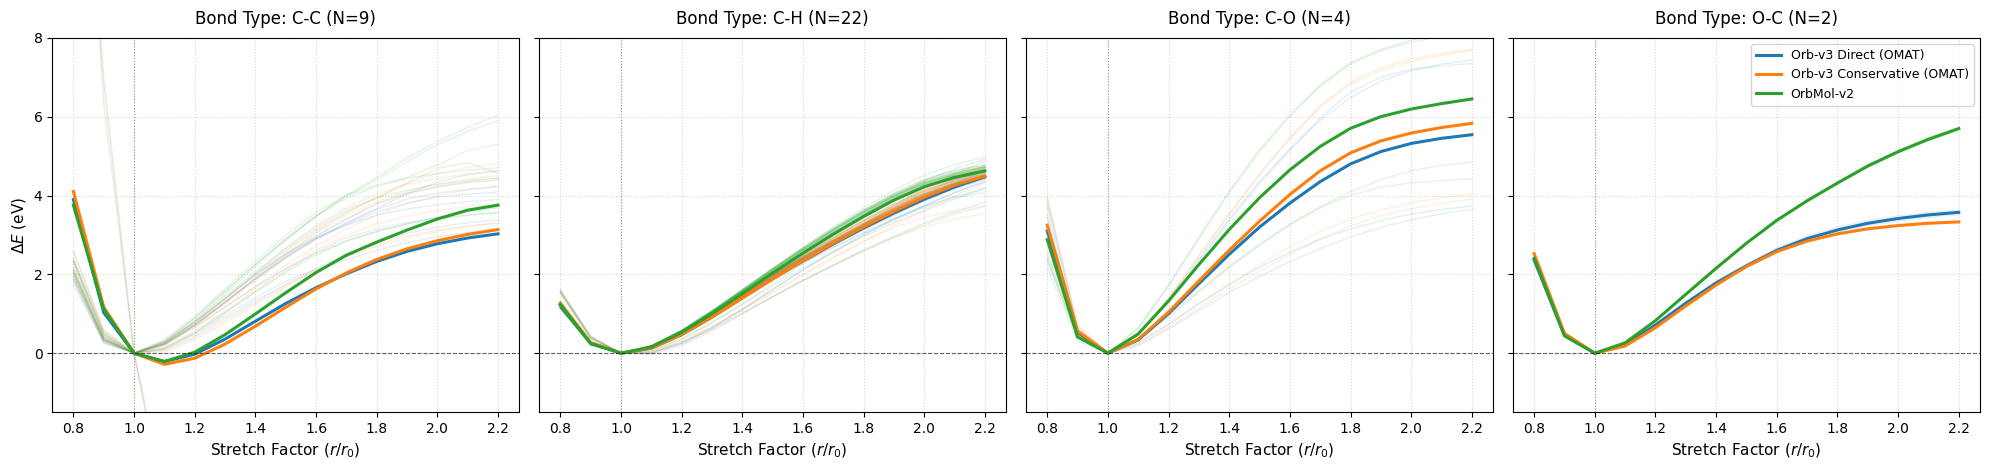

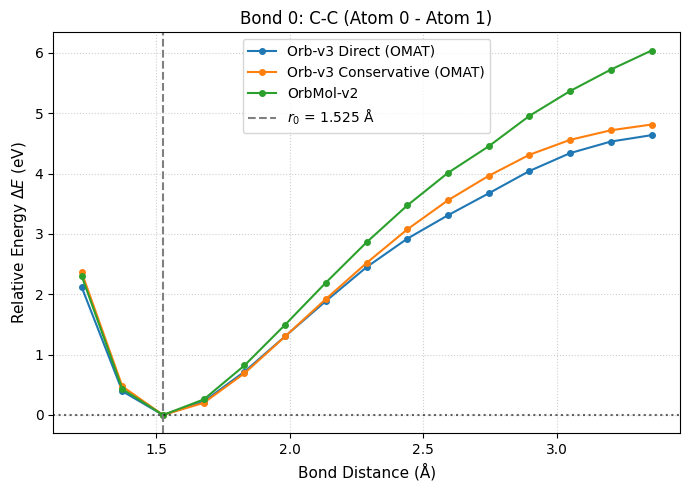

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_bond_benchmark(
    csv_path: str = "orb_mlip_bond_scans.csv",
    output_fig: str = "orb_pec_comparison.png",
    energy_unit: str = "eV",  # 'eV' or 'kcal/mol'
):
    df = pd.read_csv(csv_path)

    # Conversion factor from eV
    conv = 23.060548 if energy_unit == "kcal/mol" else 1.0
    model_cols = [c for c in df.columns if c.startswith("E_")]
    model_labels = {
        "E_orb_v3_direct_omat": "Orb-v3 Direct (OMAT)",
        "E_orb_v3_conservative_omat": "Orb-v3 Conservative (OMAT)",
        "E_orbmol_v2": "OrbMol-v2",
    }

    # Calculate relative energies per bond and per model: Delta_E = E(r) - E(r0)
    for m in model_cols:
        delta_col = f"dE_{m}"
        # Baseline at stretch_factor closest to 1.0
        baseline = (
            df.groupby("bond_id")[m]
            .transform(
                lambda s: s.iloc[(df.loc[s.index, "stretch_factor"] - 1.0).abs().argmin()]
            )
        )
        df[delta_col] = (df[m] - baseline) * conv

    # Unique bond types in the molecule (e.g., C-C, C-H, C-O)
    bond_types = sorted(df["bond_type"].unique())
    num_types = len(bond_types)

    palette = {
        "E_orb_v3_direct_omat": "#1f77b4",
        "E_orb_v3_conservative_omat": "#ff7f0e",
        "E_orbmol_v2": "#2ca02c",
    }

    fig, axes = plt.subplots(1, num_types, figsize=(5 * num_types, 4.8), sharey=True)
    if num_types == 1:
        axes = [axes]

    for ax, b_type in zip(axes, bond_types):
        sub_df = df[df["bond_type"] == b_type]
        unique_bonds = sub_df["bond_id"].unique()

        # Plot individual bond traces with low alpha, model mean with solid thick line
        for m in model_cols:
            d_col = f"dE_{m}"
            label = model_labels.get(m, m)
            color = palette.get(m, "gray")

            # Thin individual traces
            for b_id in unique_bonds:
                b_data = sub_df[sub_df["bond_id"] == b_id]
                ax.plot(
                    b_data["stretch_factor"],
                    b_data[d_col],
                    color=color,
                    alpha=0.12,
                    linewidth=1.0,
                )

            # Mean trend line across this bond type
            mean_curve = sub_df.groupby("stretch_factor")[d_col].mean()
            ax.plot(
                mean_curve.index,
                mean_curve.values,
                color=color,
                label=label,
                linewidth=2.2,
            )

        ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.axvline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.8)
        ax.set_title(f"Bond Type: {b_type} (N={len(unique_bonds)})", fontsize=12, pad=10)
        ax.set_xlabel(r"Stretch Factor ($r / r_0$)", fontsize=11)
        ax.set_ylim(-1.5 * conv, 8.0 * conv)
        ax.grid(True, linestyle=":", alpha=0.5)

    axes[0].set_ylabel(rf"$\Delta E$ ({energy_unit})", fontsize=11)
    axes[-1].legend(frameon=True, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(output_fig, dpi=300)
    print(f"Saved overview plot to '{output_fig}'")


def plot_single_bond_detail(
    bond_id: int,
    csv_path: str = "orb_mlip_bond_scans.csv",
    output_fig: str = "single_bond_detail.png",
):
    """Plots distance (in Angstroms) vs potential energy for one specific bond."""
    df = pd.read_csv(csv_path)
    b_df = df[df["bond_id"] == bond_id].copy()

    if b_df.empty:
        raise ValueError(f"Bond ID {bond_id} not found in {csv_path}")

    b_type = b_df["bond_type"].iloc[0]
    atom_i = b_df["atom_i"].iloc[0]
    atom_j = b_df["atom_j"].iloc[0]
    r0 = b_df["r0"].iloc[0]

    model_cols = [c for c in df.columns if c.startswith("E_")]
    model_labels = {
        "E_orb_v3_direct_omat": "Orb-v3 Direct (OMAT)",
        "E_orb_v3_conservative_omat": "Orb-v3 Conservative (OMAT)",
        "E_orbmol_v2": "OrbMol-v2",
    }
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    plt.figure(figsize=(7, 5))
    for m, col in zip(model_cols, colors):
        label = model_labels.get(m, m)
        # Shift each to zero at equilibrium
        idx_r0 = (b_df["stretch_factor"] - 1.0).abs().argmin()
        dE = b_df[m] - b_df[m].iloc[idx_r0]
        plt.plot(b_df["distance"], dE, marker="o", markersize=4, label=label, color=col)

    plt.axvline(r0, color="gray", linestyle="--", label=f"$r_0$ = {r0:.3f} Å")
    plt.axhline(0, color="black", linestyle=":", alpha=0.6)
    plt.title(f"Bond {bond_id}: {b_type} (Atom {atom_i} - Atom {atom_j})", fontsize=12)
    plt.xlabel("Bond Distance (Å)", fontsize=11)
    plt.ylabel(r"Relative Energy $\Delta E$ (eV)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(output_fig, dpi=300)
    print(f"Saved single bond scan plot to '{output_fig}'")


if __name__ == "__main__":
    # 1. Summary plot grouped by chemical bond type (C-C, C-O, C-H)
    plot_bond_benchmark(
        csv_path="orb_mlip_bond_scans.csv",
        output_fig="orb_pec_comparison.png",
        energy_unit="eV",
    )

    # 2. Detailed curve for a specific bond (e.g., bond_id=0)
    plot_single_bond_detail(
        bond_id=0,
        csv_path="orb_mlip_bond_scans.csv",
        output_fig="single_bond_0_detail.png",
    )